In [ ]:
import requests
import os
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


In [ ]:
item_id = "TrollPelt"
condense,has_sold = True,True
interval = '3m' # smallest accepted interval is 3m
start,end = '2025-10-07','2025-10-14'
limit,page = '50','1'

def url():
    url = (
        f'https://api.darkerdb.com/v1/market/analytics/{item_id}/prices/history'
        f'?key={os.getenv("dark_api_key")}'
        f'&interval={interval}'
        f'&from={start}&to={end}'
    )
    return url
req = requests.get(url())

In [264]:
with requests.Session() as ses:
    bodyList = []
    get = 1
    req = ses.get(url())

    while req.json()['body'] != []:
        bodyList.extend(req.json()['body'])
        end = req.json()['body'][0]['timestamp']
        req = ses.get(url())

        print(f'{get}', end="\r")
        get += 1
df = pd.json_normalize(bodyList, sep=',')
# df

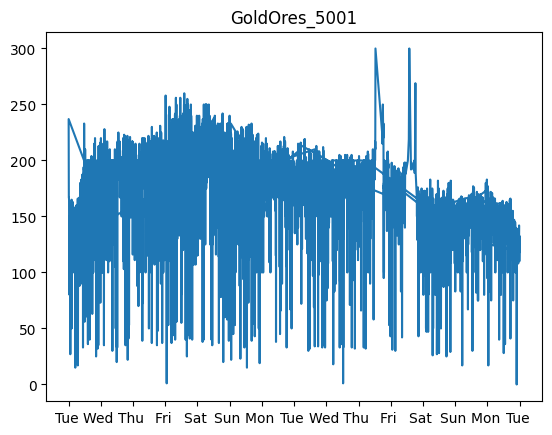

In [265]:
# ensure timestamps are datetimes for hourly locators
df['timestamp'] = pd.to_datetime(df['timestamp'])

fig, ax = plt.subplots()
ax.plot(df['timestamp'], df['min'])
ax.set_title(f"{item_id}" )
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a '))
